# Ensemble Model
**DSC 148 Final Project**

Combines probability outputs from all six individual models using AUC-weighted averaging: each model's test probabilities are weighted by its validation AUC score, so stronger models contribute more to the final prediction.

> Run notebooks 02 through 07 first so all results/*.npy and results/*.json files exist.

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json, os
from sklearn.metrics import (
    classification_report, roc_auc_score, roc_curve,
    f1_score, precision_score, recall_score, accuracy_score
)
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 100
print('Libraries loaded.')

Libraries loaded.


## 1. Load Saved Outputs

In [19]:
# Ensemble uses only tree-based models (LGB, XGB, CatBoost, RF).
# Baselines (LR, NB) excluded: weaker models with different probability scales
# would dilute the ensemble rather than improve it.
MODEL_REGISTRY = [
    ('LightGBM',            'results/lgbm_metrics.json',     'results/lgbm_probs.npy',     'results/lgbm_val_probs.npy'),
    ('XGBoost',             'results/xgb_metrics.json',      'results/xgb_probs.npy',      'results/xgb_val_probs.npy'),
    ('CatBoost',            'results/catboost_metrics.json', 'results/catboost_probs.npy', 'results/catboost_val_probs.npy'),
    ('Random Forest',       'results/rf_metrics.json',       'results/rf_probs.npy',       'results/rf_val_probs.npy'),
]

y_test = np.load('results/y_test.npy')

loaded = []
for name, mf, pf, vf in MODEL_REGISTRY:
    try:
        with open(mf) as f:
            m = json.load(f)
        test_probs = np.load(pf)
        val_probs  = np.load(vf) if os.path.exists(vf) else None
        loaded.append({'name': name, 'metrics': m, 'test_probs': test_probs, 'val_probs': val_probs})
        vnote = 'val+test' if val_probs is not None else 'test only'
        print(f'  OK  {name:<22s}  AUC={m["auc"]:.4f}  F1={m["f1"]:.4f}  ({vnote})')
    except FileNotFoundError as e:
        print(f'  MISSING  {name}: {e}')

print(f'\nLoaded {len(loaded)} / {len(MODEL_REGISTRY)} models.')

  OK  LightGBM                AUC=0.8420  F1=0.3663  (val+test)
  OK  XGBoost                 AUC=0.9045  F1=0.5443  (val+test)
  OK  CatBoost                AUC=0.8864  F1=0.4724  (val+test)
  OK  Random Forest           AUC=0.8802  F1=0.4476  (val+test)

Loaded 4 / 4 models.


## 2. AUC-Weighted Ensemble

In [20]:
from scipy.stats import rankdata

def rank_norm(arr):
    return rankdata(arr) / len(arr)

aucs    = np.array([m['metrics']['auc'] for m in loaded])
weights = aucs / aucs.sum()
print('Model weights (proportional to val AUC):')
for m, w in zip(loaded, weights):
    print(f'  {m["name"]:<22s}  AUC={m["metrics"]["auc"]:.4f}  weight={w:.4f}')

ensemble_probs = sum(w * m['test_probs'] for w, m in zip(weights, loaded))

loaded_val = [m for m in loaded if m['val_probs'] is not None]
if loaded_val:
    aucs_val       = np.array([m['metrics']['auc'] for m in loaded_val])
    weights_val    = aucs_val / aucs_val.sum()
    ensemble_val   = sum(w * m['val_probs'] for w, m in zip(weights_val, loaded_val))
    print(f'\nVal probs available for {len(loaded_val)} models.')
else:
    ensemble_val = None

Model weights (proportional to val AUC):
  LightGBM                AUC=0.8420  weight=0.2397
  XGBoost                 AUC=0.9045  weight=0.2575
  CatBoost                AUC=0.8864  weight=0.2523
  Random Forest           AUC=0.8802  weight=0.2506

Val probs available for 4 models.


In [21]:
if ensemble_val is not None:
    try:
        y_val = np.load('results/y_val.npy')
        thr_range = np.linspace(ensemble_val.min()+1e-4, ensemble_val.max()-1e-4, 300)
        best_ens = float(thr_range[int(np.argmax(
            [f1_score(y_val, (ensemble_val>=t).astype(int), zero_division=0) for t in thr_range]
        ))])
        print(f'Optimal ensemble threshold (val): {best_ens:.4f}')
    except FileNotFoundError:
        best_ens = 0.5
        print('results/y_val.npy not found -- using threshold=0.5')
else:
    best_ens = 0.5

y_pred_ens = (ensemble_probs >= best_ens).astype(int)
print(f'Threshold: {best_ens:.4f}')
print('='*35)
print('Ensemble -- Test Set')
print('='*35)
print(classification_report(y_test, y_pred_ens, target_names=['Legitimate','Fraud']))
print(f'AUC-ROC : {roc_auc_score(y_test, ensemble_probs):.4f}')

Optimal ensemble threshold (val): 0.5578
Threshold: 0.5578
Ensemble -- Test Set
              precision    recall  f1-score   support

  Legitimate       0.98      0.99      0.98     56841
       Fraud       0.60      0.45      0.52      2213

    accuracy                           0.97     59054
   macro avg       0.79      0.72      0.75     59054
weighted avg       0.96      0.97      0.97     59054

AUC-ROC : 0.9057


## 2b. Optimized Weights (val AUC)

Uses `scipy.optimize.minimize` (Nelder-Mead) to find ensemble weights that maximize val-set AUC. Val probs are rank-normalized before optimization for comparability across models.

In [22]:
from scipy.optimize import minimize

if loaded_val:
    ranked_val  = [rank_norm(m['val_probs'])  for m in loaded_val]
    ranked_test = [rank_norm(m['test_probs']) for m in loaded_val]

    def neg_auc(w):
        w_pos = np.abs(w) / (np.abs(w).sum() + 1e-12)
        ens = sum(wi * rv for wi, rv in zip(w_pos, ranked_val))
        return -roc_auc_score(y_val, ens)

    w0  = np.ones(len(loaded_val)) / len(loaded_val)
    res = minimize(neg_auc, w0, method='Nelder-Mead',
                   options={'maxiter': 5000, 'xatol': 1e-5, 'fatol': 1e-5})
    opt_w = np.abs(res.x) / np.abs(res.x).sum()

    print('Optimized weights (val AUC = {:.4f}):'.format(-res.fun))
    for m, w in zip(loaded_val, opt_w):
        print(f"  {m['name']:<22s}  weight={w:.4f}")

    ensemble_probs_opt = sum(wi * rt for wi, rt in zip(opt_w, ranked_test))
    ensemble_val_opt   = sum(wi * rv for wi, rv in zip(opt_w, ranked_val))

    thr_range = np.linspace(ensemble_val_opt.min()+1e-4, ensemble_val_opt.max()-1e-4, 300)
    best_opt  = float(thr_range[int(np.argmax(
        [f1_score(y_val, (ensemble_val_opt>=t).astype(int), zero_division=0) for t in thr_range]
    ))])
    y_pred_opt = (ensemble_probs_opt >= best_opt).astype(int)

    print(f'\nOptimized ensemble -- Test Set')
    print('='*35)
    print(classification_report(y_test, y_pred_opt, target_names=['Legitimate','Fraud']))
    print(f'AUC-ROC (optimized) : {roc_auc_score(y_test, ensemble_probs_opt):.4f}')
    print(f'AUC-ROC (AUC-weight): {roc_auc_score(y_test, ensemble_probs):.4f}')
else:
    print('No val probs -- skipping optimization.')
    ensemble_probs_opt = ensemble_probs
    y_pred_opt = y_pred_ens

Optimized weights (val AUC = 0.9262):
  LightGBM                weight=0.0000
  XGBoost                 weight=0.8025
  CatBoost                weight=0.0000
  Random Forest           weight=0.1975

Optimized ensemble -- Test Set
              precision    recall  f1-score   support

  Legitimate       0.98      0.99      0.98     56841
       Fraud       0.64      0.46      0.53      2213

    accuracy                           0.97     59054
   macro avg       0.81      0.72      0.76     59054
weighted avg       0.97      0.97      0.97     59054

AUC-ROC (optimized) : 0.9065
AUC-ROC (AUC-weight): 0.9057


## 3. Full Model Comparison

In [23]:
rows = {}
for m in loaded:
    rows[m['name']] = {
        'Accuracy'         : round(m['metrics']['accuracy'],  4),
        'Precision (Fraud)': round(m['metrics']['precision'], 4),
        'Recall (Fraud)'   : round(m['metrics']['recall'],    4),
        'F1 (Fraud)'       : round(m['metrics']['f1'],        4),
        'AUC-ROC'          : round(m['metrics']['auc'],       4),
    }
rows['Ensemble (AUC-weight)'] = {
    'Accuracy'         : round(float(accuracy_score(y_test, y_pred_ens)), 4),
    'Precision (Fraud)': round(float(precision_score(y_test, y_pred_ens, zero_division=0)), 4),
    'Recall (Fraud)'   : round(float(recall_score(y_test, y_pred_ens, zero_division=0)), 4),
    'F1 (Fraud)'       : round(float(f1_score(y_test, y_pred_ens, zero_division=0)), 4),
    'AUC-ROC'          : round(float(roc_auc_score(y_test, ensemble_probs)), 4),
}
rows['Ensemble (optimized)'] = {
    'Accuracy'         : round(float(accuracy_score(y_test, y_pred_opt)), 4),
    'Precision (Fraud)': round(float(precision_score(y_test, y_pred_opt, zero_division=0)), 4),
    'Recall (Fraud)'   : round(float(recall_score(y_test, y_pred_opt, zero_division=0)), 4),
    'F1 (Fraud)'       : round(float(f1_score(y_test, y_pred_opt, zero_division=0)), 4),
    'AUC-ROC'          : round(float(roc_auc_score(y_test, ensemble_probs_opt)), 4),
}

results_df = pd.DataFrame(rows).T
print('Table: Full Model Comparison (test set)')
print(results_df.to_string())

Table: Full Model Comparison (test set)
                       Accuracy  Precision (Fraud)  Recall (Fraud)  F1 (Fraud)  AUC-ROC
LightGBM                 0.9593             0.4404          0.3136      0.3663   0.8420
XGBoost                  0.9710             0.6617          0.4623      0.5443   0.9045
CatBoost                 0.9655             0.5534          0.4121      0.4724   0.8864
Random Forest            0.9650             0.5481          0.3782      0.4476   0.8802
Ensemble (AUC-weight)    0.9682             0.6006          0.4532      0.5166   0.9057
Ensemble (optimized)     0.9700             0.6389          0.4573      0.5331   0.9065


## 4. ROC Curves

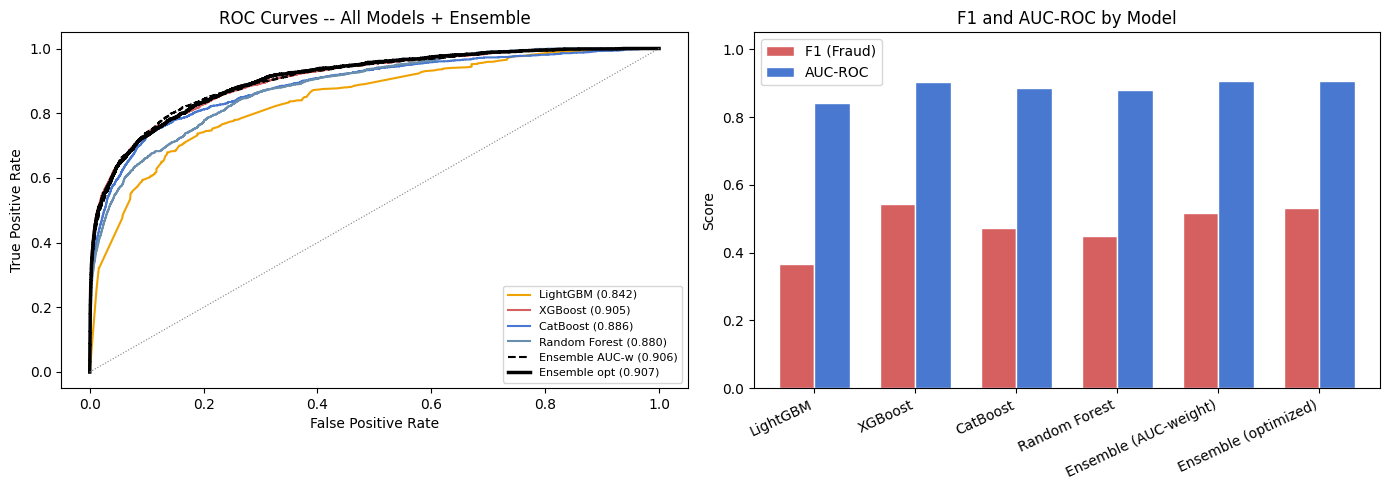

In [24]:
COLORS = ['#F0A202','#D65F5F','#4878CF','#6A8EAE','#A0522D','#808080']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, m in enumerate(loaded):
    fpr, tpr, _ = roc_curve(y_test, m['test_probs'])
    axes[0].plot(fpr, tpr, color=COLORS[i % len(COLORS)],
                 label=f"{m['name']} ({m['metrics']['auc']:.3f})", linewidth=1.5)

fpr_e, tpr_e, _ = roc_curve(y_test, ensemble_probs)
axes[0].plot(fpr_e, tpr_e, color='black', linewidth=1.5, linestyle='--',
             label=f"Ensemble AUC-w ({roc_auc_score(y_test, ensemble_probs):.3f})")
fpr_o, tpr_o, _ = roc_curve(y_test, ensemble_probs_opt)
axes[0].plot(fpr_o, tpr_o, color='black', linewidth=2.5,
             label=f"Ensemble opt ({roc_auc_score(y_test, ensemble_probs_opt):.3f})")
axes[0].plot([0,1],[0,1],'grey',linewidth=0.8,linestyle=':')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves -- All Models + Ensemble')
axes[0].legend(loc='lower right', fontsize=8)

results_df[['F1 (Fraud)','AUC-ROC']].plot(
    kind='bar', ax=axes[1], color=['#D65F5F','#4878CF'], edgecolor='white', width=0.7)
axes[1].set_title('F1 and AUC-ROC by Model')
axes[1].set_ylabel('Score')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=25, ha='right')
axes[1].set_ylim(0, 1.05)
axes[1].legend()
plt.tight_layout()
plt.show()